# 2.5D annular model and efficiency map

The annular model splits the disk machine into radial slices and evaluates the
field, torque contribution, yoke loading, and losses per slice. Because torque
and back-EMF derive from the same summed flux linkage, the model agrees with
the Layer-1 analytical model *to machine precision* for a perfect machine —
the extra fidelity appears only where physics is genuinely radius-dependent.

In [1]:
import dataclasses
from pathlib import Path

from axfluxmdo import AxialFluxMotor, OperatingPoint
from axfluxmdo.models import AnalyticalModel, AnnularModel, compute_efficiency_map
from axfluxmdo.viz import plot_efficiency_map, plot_radial_profiles

OUTPUT_DIR = Path(__file__).parent / "output" if "__file__" in globals() else Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

motor = AxialFluxMotor(
    outer_radius=0.08,
    inner_radius=0.025,
    air_gap=0.0008,
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,
    back_iron_thickness=0.006,
)
op = OperatingPoint(speed_rpm=500, current_rms=25, dc_bus_voltage=48)

## Layer-1 / Layer-2 parity

For a perfect axisymmetric machine the two layers agree exactly — a strong
correctness check on both.

In [2]:
analytical = AnalyticalModel().evaluate(motor, op)
annular = AnnularModel(n_slices=32).evaluate(motor, op)
print(f"analytical torque: {analytical.torque_nm:.6f} N·m")
print(f"annular torque:    {annular.torque_nm:.6f} N·m")
print(f"relative diff:     {abs(annular.torque_nm / analytical.torque_nm - 1):.2e}")

analytical torque: 8.629426 N·m
annular torque:    8.629426 N·m
relative diff:     0.00e+00


## Radial profiles

Where the fidelity shows up: yoke flux density grows with radius (pole pitch
τ_p = πr/p widens outward), so saturation binds at the outer radius first —
the Layer-1 mean-radius proxy underestimates it.

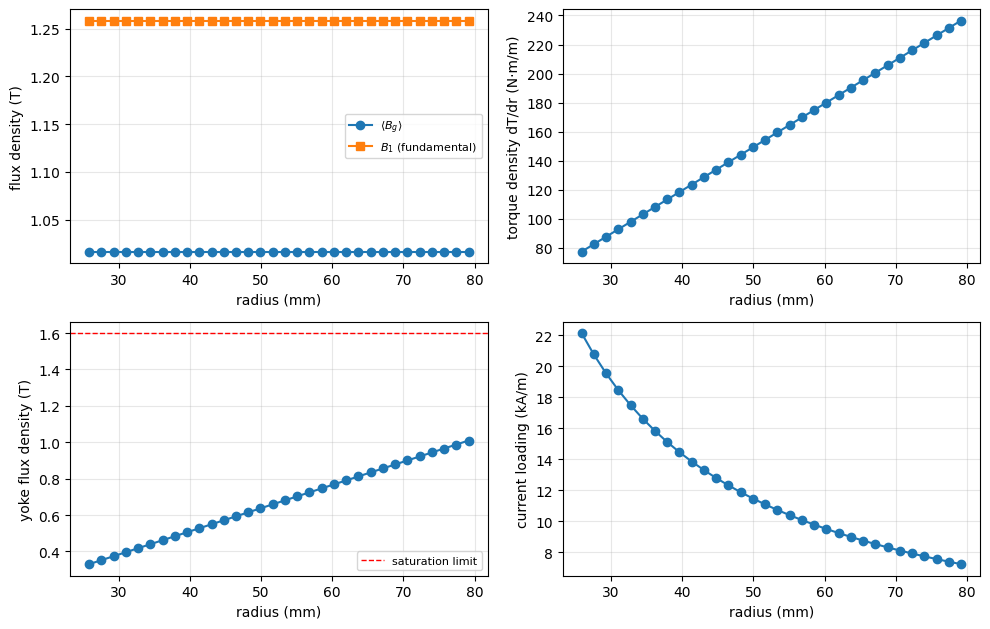

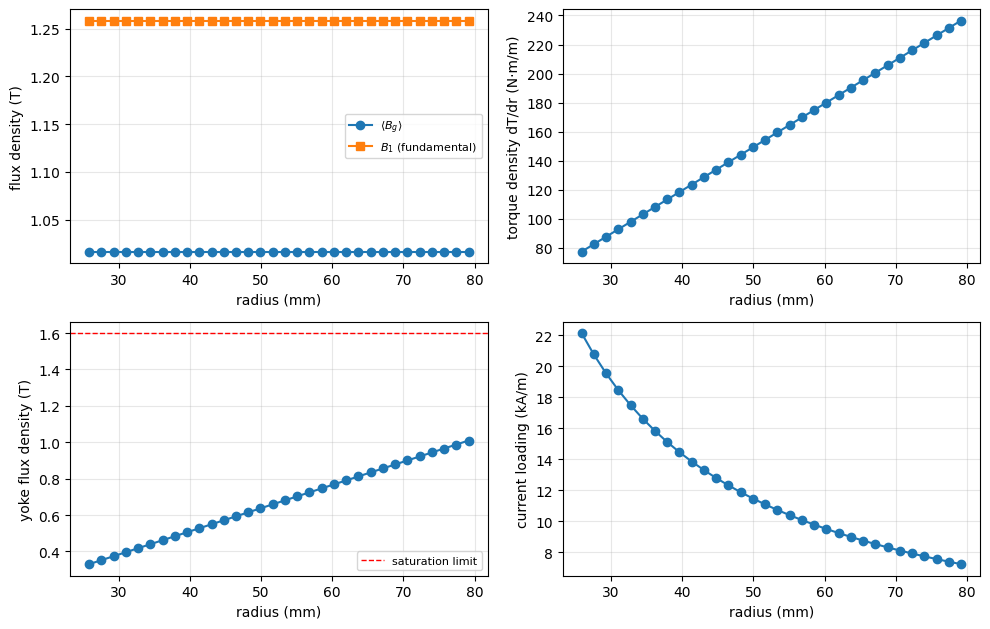

In [3]:
fig = plot_radial_profiles(annular)
fig.savefig(OUTPUT_DIR / "03_radial_profiles.png", dpi=150, bbox_inches="tight")
fig

## Pole-pitch effect on yoke loading

Fewer pole pairs → wider poles → more flux per pole returning through the
same yoke → saturation. This is why the p = 4 variant was infeasible in
example 02.

In [4]:
for p in (8, 14, 20):
    r = AnnularModel(n_slices=32).evaluate(dataclasses.replace(motor, pole_pairs=p), op)
    print(
        f"p={p:3d}  B_yoke at r_i={r.slice_yoke_b_t[0]:.2f} T, "
        f"at r_o={r.slice_yoke_b_t[-1]:.2f} T  (limit 1.6 T)"
    )

p=  8  B_yoke at r_i=0.58 T, at r_o=1.77 T  (limit 1.6 T)
p= 14  B_yoke at r_i=0.33 T, at r_o=1.01 T  (limit 1.6 T)
p= 20  B_yoke at r_i=0.23 T, at r_o=0.71 T  (limit 1.6 T)


## Wedge vs rectangular magnets

Rectangular magnets (constant width) over-cover the pole at small radii
(clipped at full coverage) and under-cover at large radii, where most of the
torque is produced — so they trade a few percent of torque for simpler
magnet procurement.

In [5]:
rect = AnnularModel(n_slices=32).evaluate(
    dataclasses.replace(motor, magnet_shape="rectangular"), op
)
delta = rect.torque_nm / annular.torque_nm - 1
print(f"wedge torque:       {annular.torque_nm:.3f} N·m")
print(f"rectangular torque: {rect.torque_nm:.3f} N·m  ({delta:+.1%})")

wedge torque:       8.629 N·m
rectangular torque: 8.102 N·m  (-6.1%)


## Efficiency map over the speed–torque plane

Constraint-aware: grey cells violate at least one limit (thermal, current
density, voltage, electrical frequency). The map takes ~1600 model
evaluations and runs in well under a second.

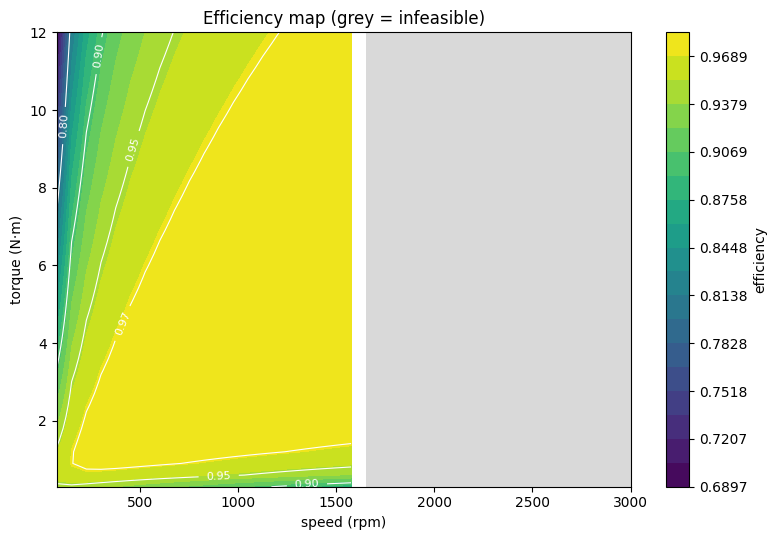

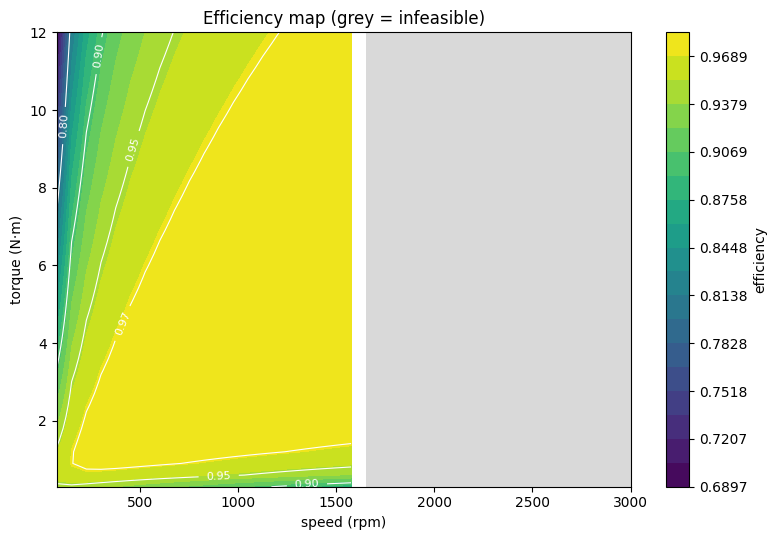

In [6]:
emap = compute_efficiency_map(motor, op, max_speed_rpm=3000, max_torque_nm=12)
fig = plot_efficiency_map(emap)
fig.savefig(OUTPUT_DIR / "03_efficiency_map.png", dpi=150, bbox_inches="tight")
fig